=== RÉGRESSION LOGISTIQUE ===
              precision    recall  f1-score   support

           0       0.79      1.00      0.88   1650373
           1       0.38      0.00      0.00    445196

    accuracy                           0.79   2095569
   macro avg       0.58      0.50      0.44   2095569
weighted avg       0.70      0.79      0.69   2095569

ROC-AUC : 0.526873120890831


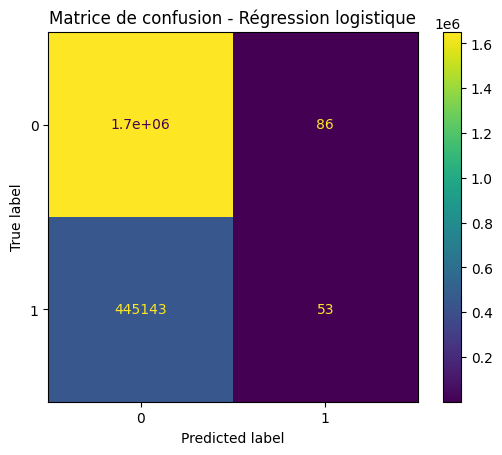

Coefficients de la régression logistique :
is_weekend           0.077284
hour                 0.042133
Precipitation(in)    0.023566
Temperature(F)      -0.002425
Visibility(mi)      -0.002565
dtype: float64

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.79      1.00      0.88   1650373
           1       0.73      0.00      0.00    445196

    accuracy                           0.79   2095569
   macro avg       0.76      0.50      0.44   2095569
weighted avg       0.78      0.79      0.69   2095569

ROC-AUC : 0.5650569583673752


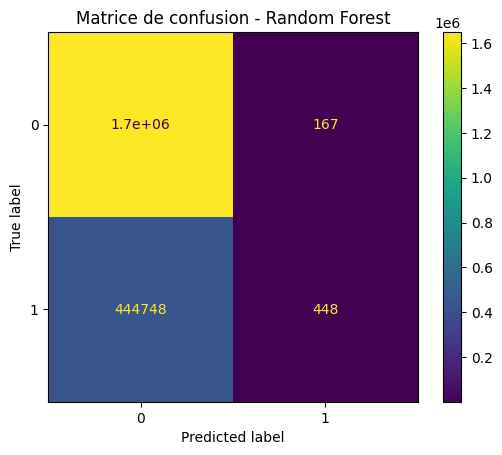

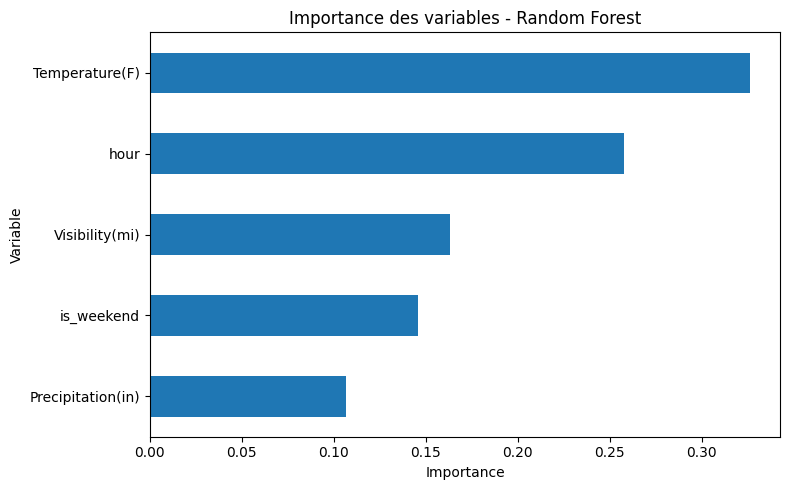


Comparaison des modèles :
                 Model   ROC_AUC
0  Logistic Regression  0.526873
1        Random Forest  0.565057


In [3]:
# ============================================
# MODÉLISATION – ACCIDENTS DE LA ROUTE (US)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# --------------------------------------------
# 1. Chargement des données
# --------------------------------------------
df = pd.read_csv('../data/processed/us_accidents_clean.csv')

# --------------------------------------------
# 2. Création de la variable cible
# --------------------------------------------
df['Severe'] = (df['Severity'] >= 3).astype(int)

# --------------------------------------------
# 3. Sélection des variables explicatives
# --------------------------------------------
features = [
    'Visibility(mi)',
    'Precipitation(in)',
    'Temperature(F)',
    'is_weekend',
    'hour'
]

model_df = df[features + ['Severe']].dropna()

X = model_df[features]
y = model_df['Severe']

# --------------------------------------------
# 4. Séparation train / test
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# --------------------------------------------
# 5. Normalisation (pour régression logistique)
# --------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# MODÈLE 1 : RÉGRESSION LOGISTIQUE
# ============================================

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_log = log_model.predict(X_test_scaled)
y_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Évaluation
print("=== RÉGRESSION LOGISTIQUE ===")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC :", roc_auc_score(y_test, y_proba_log))

# Matrice de confusion
cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log).plot()
plt.title("Matrice de confusion - Régression logistique")
plt.show()

# Coefficients du modèle
coefficients = pd.Series(
    log_model.coef_[0],
    index=features
).sort_values(ascending=False)

print("Coefficients de la régression logistique :")
print(coefficients)

# ============================================
# MODÈLE 2 : RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Évaluation
print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC :", roc_auc_score(y_test, y_proba_rf))

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Matrice de confusion - Random Forest")
plt.show()

# --------------------------------------------
# Importance des variables
# --------------------------------------------
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='barh')
plt.title("Importance des variables - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# ============================================
# COMPARAISON DES MODÈLES
# ============================================

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC_AUC': [
        roc_auc_score(y_test, y_proba_log),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

print("\nComparaison des modèles :")
print(results)
